In [1]:
from pathlib import Path
import h5py


In [6]:

hdf5 = Path("/mnt/gestalt/home/tkwang/MOSA_ver2/hdf5s/mosa/de1_ev01_t2.h5")

with h5py.File(hdf5, 'r') as hf:
    print("Keys in hdf5 file:")
    for key in hf.keys():
        print(key)

Keys in hdf5 file:
midi_event
midi_event_time
waveform


int16
(1970240,)


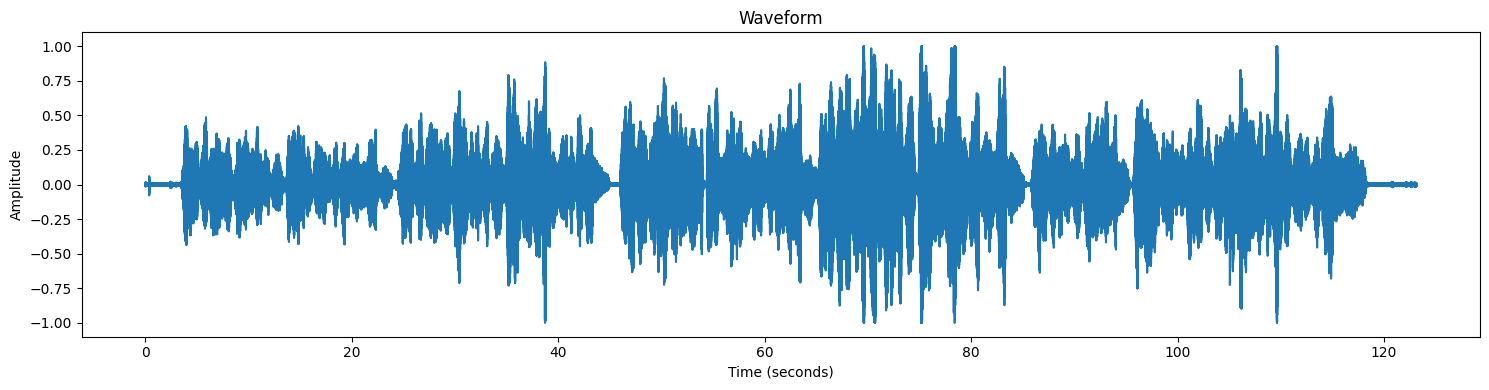

In [8]:
import matplotlib.pyplot as plt
import numpy as np

with h5py.File(hdf5, 'r') as hf:
    waveform = hf['waveform'][:]

    print(waveform.dtype)
    print(waveform.shape)
    # If int16, convert to float32 for plotting
    if waveform.dtype == np.int16:
        waveform = waveform.astype(np.float32) / 32768.0

# Calculate time axis based on sample rate (assuming 16000 Hz from context)
sample_rate = 16000  # Hz
time_axis = np.arange(len(waveform)) / sample_rate

plt.figure(figsize=(15, 4))
plt.plot(time_axis, waveform)
plt.title("Waveform")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.tight_layout()
plt.show()
